# Full EDA Notebook — Diabetic Dataset

This notebook performs a thorough exploratory data analysis (EDA) on `diabetic_data.csv`. It includes data loading, cleaning, missing-value analysis, visualizations, feature engineering, and outputs a cleaned dataset ready for modeling.

**What this notebook will produce:**
- Data summary and diagnostics
- Missing value analysis and strategies
- Visualizations for numerical and categorical features (matplotlib)
- Target analysis and class balance
- Correlation analysis and feature selection hints
- Feature engineering and encoding examples
- Cleaned dataset saved to `feature_engineered_diabetes.csv`

---

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


In [ ]:

df = pd.read_csv("dataset/diabetic_data.csv")
df.head(5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [111]:
df.replace("?", np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [112]:
df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [113]:
df.drop(["encounter_id","patient_nbr", "weight", "payer_code"], axis=1, inplace=True)

In [114]:
# Categorical columns → fill with "Missing"
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Missing")

# Numeric columns → fill with median
num_cols = df.select_dtypes(exclude=['object']).columns
df[num_cols] = df[num_cols].apply(lambda x: x.fillna(x.median()))


#### 1. Categorical Columns

#### All categorical features (object type) have missing values replaced with the placeholder "Missing".
#### This preserves the category structure without introducing bias from arbitrary imputation.

#### 2. Numerical Columns

#### Numerical features are imputed using the median, which is robust to outliers and preserves the data distribution.

# EDA

#### Data Visualization and Insights 

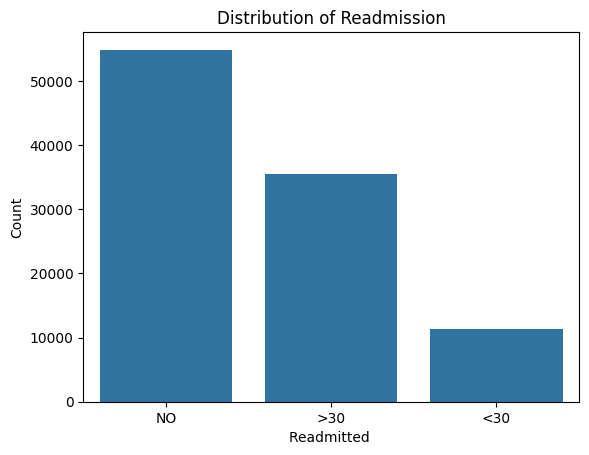

In [115]:
sns.countplot(x='readmitted', data=df)
plt.title("Distribution of Readmission")
plt.xlabel("Readmitted ")
plt.ylabel("Count")
plt.show()

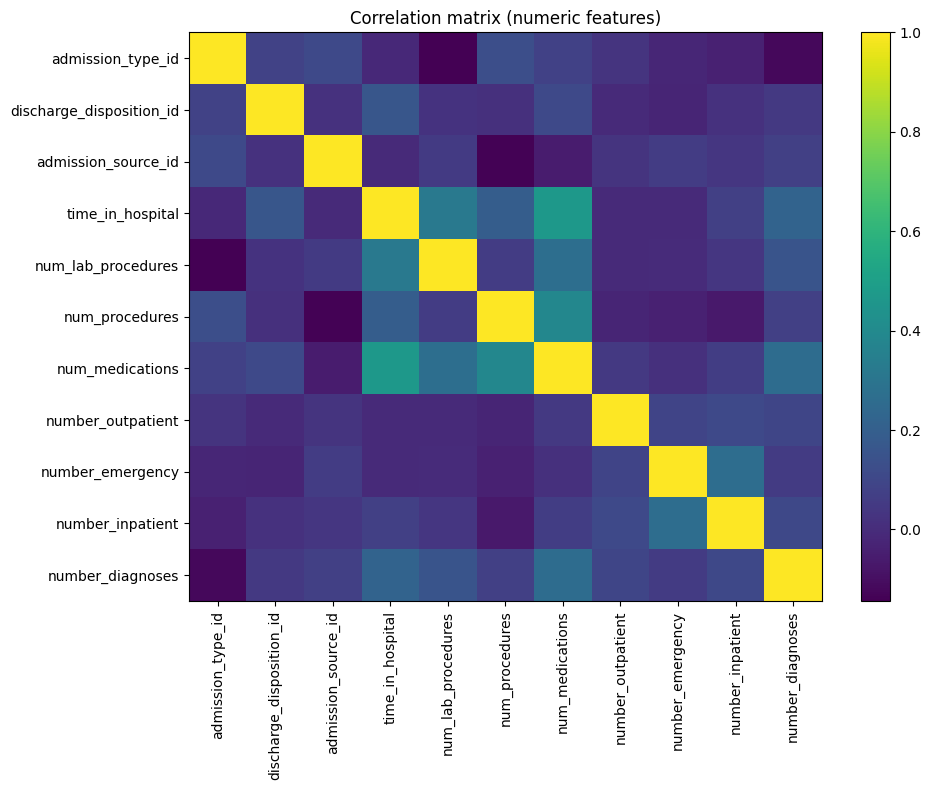

In [132]:
# Correlation heatmap for numeric features (Pearson)
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    plt.imshow(corr, aspect='auto', interpolation='none')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation matrix.")

#### Demographics 

Text(0.5, 1.0, 'Age Distribution of Patients')

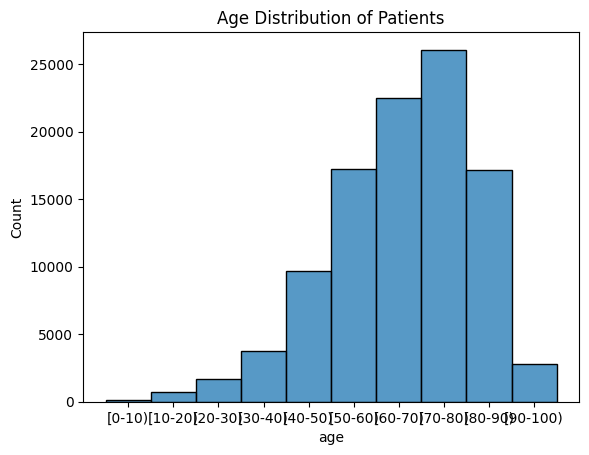

In [116]:
sns.histplot(df['age'], bins=10)
plt.title("Age Distribution of Patients")

Text(0.5, 1.0, 'Readmission by Gender')

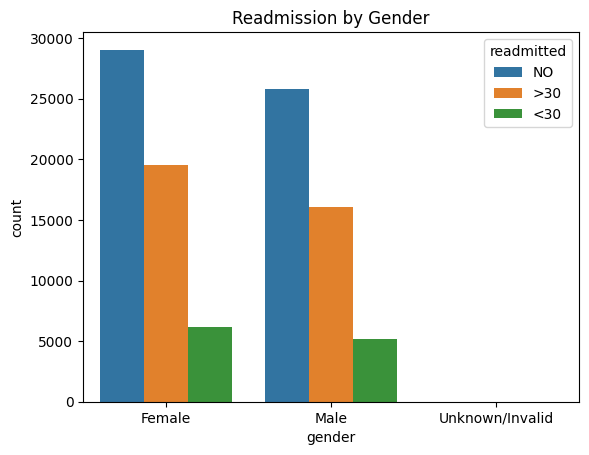

In [117]:
sns.countplot(x='gender', hue='readmitted', data=df)
plt.title("Readmission by Gender")

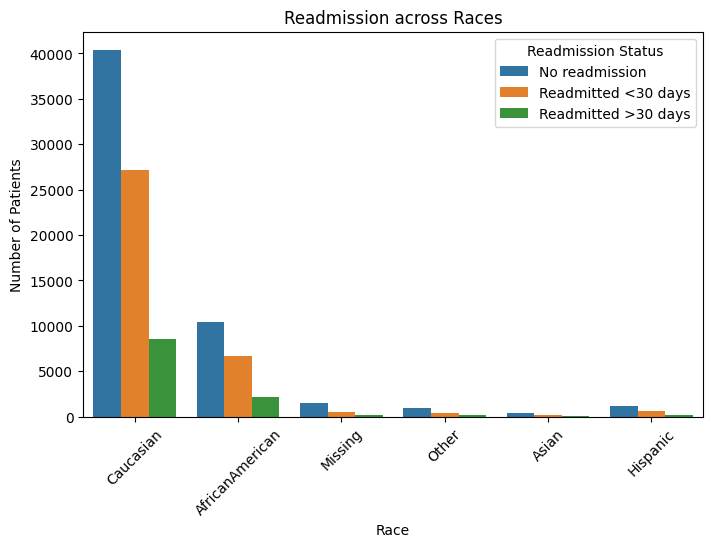

In [118]:
plt.figure(figsize=(8,5))
sns.countplot(x='race', hue='readmitted', data=df)
plt.title("Readmission across Races")
plt.xlabel("Race")
plt.ylabel("Number of Patients")

# Add proper legend labels (based on your encoding)
plt.legend(
    title="Readmission Status",
    labels=['No readmission', 'Readmitted <30 days', 'Readmitted >30 days']
)

plt.xticks(rotation=45)
plt.show()

#### Medication and Treatment Patterns 

Text(0.5, 1.0, 'Medication Change vs Readmission')

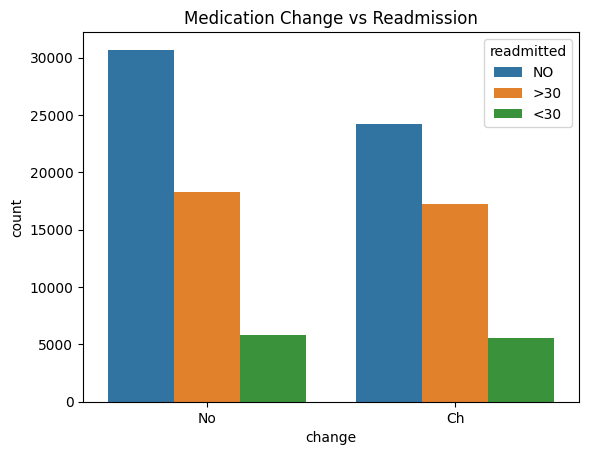

In [119]:
sns.countplot(x='change', hue='readmitted', data=df)
plt.title("Medication Change vs Readmission")

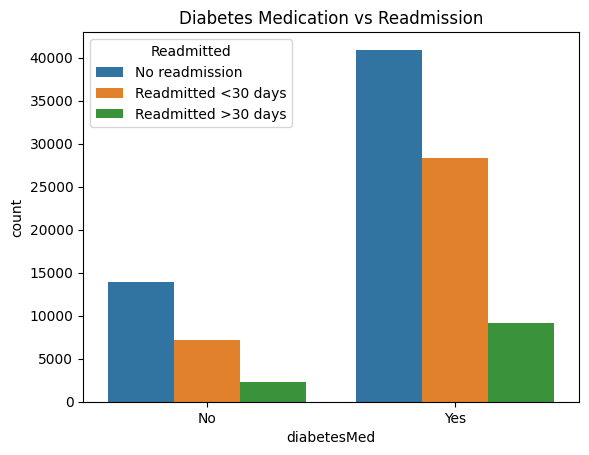

In [120]:
sns.countplot(x='diabetesMed', hue='readmitted', data=df)
plt.title("Diabetes Medication vs Readmission")
plt.legend(title='Readmitted',labels=['No readmission', 'Readmitted <30 days', 'Readmitted >30 days']
)

In [121]:
df["readmitted"] = df["readmitted"].replace({
    "<30": 1,
    ">30": 0,
    "NO": 0
})


C:\Users\Akhila Ulpara\AppData\Local\Temp\ipykernel_25408\427393067.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


# Feature Engineering

<h4> Feature engineering is the process of creating, transforming, or selecting variables that improve a machine learning model’s ability to learn patterns. It involves converting raw data into meaningful features through techniques such as encoding, scaling, combining variables, and deriving new metrics. Effective feature engineering enhances model performance, interpretability, and predictive accuracy by ensuring the inputs better represent the underlying problem.</h4>

In [122]:
def map_icd(code):
    if pd.isna(code):
        return "Missing"

    code = str(code)

    try:
        code = float(code)
    except:
        return "Other"

    if 390 <= code <= 459 or code == 785:
        return "Circulatory"
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"
    elif 250 <= code <= 250.99:
        return "Diabetes"
    elif 800 <= code <= 999:
        return "Injury"
    elif 710 <= code <= 739:
        return "Musculoskeletal"
    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"
    elif 140 <= code <= 239:
        return "Neoplasm"
    else:
        return "Other"

df["diag_1_group"] = df["diag_1"].apply(map_icd)
df["diag_2_group"] = df["diag_2"].apply(map_icd)
df["diag_3_group"] = df["diag_3"].apply(map_icd)

df.drop(["diag_1", "diag_2", "diag_3"], axis=1, inplace=True)

#### The ICD diagnosis columns (diag_1, diag_2, diag_3) contain numerical medical diagnosis codes.
#### These raw codes are difficult to interpret and contain hundreds of possible values.
#### To make them more meaningful for analysis and machine learning, we convert the ICD codes into broader

In [123]:
df["patient_severity_index"] = df["number_diagnoses"] * df["num_medications"]


#### To capture the overall medical complexity of each patient, we create a new feature called: patient_severity_index


In [124]:
df["acute_intensity"] = df["time_in_hospital"] * df["number_emergency"]


#### To better capture the short-term severity of a patient's condition, we engineer a new feature called:

#### acute_intensity

In [125]:
df["med_complexity_score"] = (
    df["num_medications"] + df["num_procedures"] + df["num_lab_procedures"]
)

#### This feature summarizes how medically complex a patient’s treatment is by combining three key factors:

#### Number of medications

#### Number of procedures

#### Number of lab procedures

In [126]:
df["diabetes_aggressiveness"] = (
    (df["insulin"] != "No").astype(int) +
    (df["metformin"] != "No").astype(int) +
    (df["change"] == "Ch").astype(int)
)

#### To quantify the intensity of diabetes management for each patient, we construct a composite feature called diabetes_aggressiveness.
#### This score reflects how actively a patient’s diabetes is being treated based on three key indicators:

#### Insulin usage

#### Metformin usage

#### Recent change in diabetes medication regimen

In [127]:
chronic_groups = {"Circulatory", "Respiratory", "Endocrine", "Neoplasms"}
df["chronic_severity"] = (
    df["diag_1_group"].isin(chronic_groups).astype(int) +
    df["diag_2_group"].isin(chronic_groups).astype(int) +
    df["diag_3_group"].isin(chronic_groups).astype(int)
)

In [128]:
high_risk_specialties = ["Cardiology", "Emergency/Trauma", "Endocrinology"]
df["specialty_risk"] = df["medical_specialty"].isin(high_risk_specialties).astype(int)

#### To assess how strongly chronic conditions contribute to a patient’s overall health burden, we create a new feature called chronic_severity.

In [129]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Missing")

In [130]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()
df[cat_cols] = encoder.fit_transform(df[cat_cols])


In [131]:
df.to_csv('feature_engineered_diabetes.csv', index=False)
